# Chapter 12. PyTorch qGAN 구현

## 개요

이 튜토리얼은 PyTorch 기반의 양자 생성적 적대 신경망(Quantum Generative Adversarial Network, qGAN) 알고리즘을 단계별로 구축하는 방법을 소개한다.

튜토리얼은 다음과 같이 구성되어 있다:

1. [소개](#1.-소개)
2. [데이터 및 표현](#2.-데이터-및-표현)
3. [신경망의 정의](#3.-신경망의-정의)
4. [훈련 루프 설정](#4.-훈련-루프-설정)
5. [모델 훈련](#5.-모델-훈련)
6. [결과: 누적 밀도 함수](#6.-결과-누적-밀도-함수)
7. [결론](#7.-결론)

## 1. 소개

qGAN [1]은 생성 모델링 작업에 사용되는 하이브리드 양자-고전 알고리즘이다. 이 알고리즘은 양자 생성기 $G_{\theta}$, 즉 매개변수가 있는 양자 회로와 고전 판별기 $D_{\phi}$, 즉 신경망의 상호작용을 이용하여 훈련 데이터로부터 기본 확률 분포를 학습한다.

생성기와 판별기는 교대로 최적화 단계에서 훈련되며, 생성기는 판별기가 훈련 데이터 값으로 분류할 확률을 생성하는 것을 목표로 한다(즉, 실제 훈련 분포의 확률). 판별기는 원본 분포와 생성기의 확률을 구분하려고 시도한다(다시 말해 실제 분포와 생성된 분포를 구분함). 최종 목표는 양자 생성기가 목표 확률 분포에 대한 표현을 학습하는 것이다.
훈련된 양자 생성기는 따라서 목표 분포의 근사 모델인 양자 상태를 로드하기 위해 사용될 수 있다.

**참고문헌:**

[1] Zoufal et al., [Quantum Generative Adversarial Networks for learning and loading random distributions](https://www.nature.com/articles/s41534-019-0223-2)

### 1.1. 무작위 분포 로딩을 위한 qGAN

$k$차원 데이터 샘플이 주어지면, 양자 생성적 적대 신경망(qGAN)을 사용하여 무작위 분포를 학습하고 이를 양자 상태로 직접 로드한다:

$$ \big| g_{\theta}\rangle = \sum_{j=0}^{2^n-1} \sqrt{p_{\theta}^{j}}\big| j \rangle $$

여기서 $p_{\theta}^{j}$는 기저 상태 $\big| j\rangle$의 발생 확률을 설명한다.

qGAN 훈련의 목표는 상태 $\big| g_{\theta}\rangle$를 생성하는 것이며, 여기서 $p_{\theta}^{j}$ ($j\in \left\{0, \ldots, {2^n-1} \right\}$)는 훈련 데이터 $X=\left\{x^0, \ldots, x^{k-1} \right\}$의 기본 분포에 가까운 확률 분포를 설명한다.

자세한 내용은 [Quantum Generative Adversarial Networks for Learning and Loading Random Distributions](https://arxiv.org/abs/1904.00043) _Zoufal, Lucchi, Woerner_ [2019]를 참고하기 바란다.

훈련된 qGAN을 애플리케이션(금융 파생상품 가격 책정)에서 어떻게 사용하는지에 대한 예제는
[qGAN을 이용한 옵션 가격 책정](https://qiskit-community.github.io/qiskit-finance/tutorials/10_qgan_option_pricing.html#) 튜토리얼을 참고하기 바란다.

## 2. 데이터 및 표현

먼저 훈련 데이터 $X$를 로드해야 한다.

이 튜토리얼에서 훈련 데이터는 2D 다변수 정규 분포로 제공된다.

생성기의 목표는 그러한 분포를 표현하는 방법을 학습하는 것이며, 훈련된 생성기는 $n$-큐비트 양자 상태에 해당해야 한다.
\begin{equation}
|g_{\text{train}}\rangle=\sum\limits_{j=0}^{k-1}\sqrt{p_{j}}|x_{j}\rangle,
\end{equation}
여기서 기저 상태 $|x_{j}\rangle$는 훈련 데이터 집합 $X={x_0, \ldots, x_{k-1}}$의 데이터 항목을 나타내며, $k\leq 2^n$이고 $p_j$는 $|x_{j}\rangle$의 샘플링 확률을 나타낸다.

이 표현을 용이하게 하기 위해 다변수 정규 분포의 샘플을 이산 값으로 매핑해야 한다. 표현할 수 있는 값의 개수는 매핑에 사용되는 큐비트의 개수에 따라 달라진다.
따라서 데이터 해상도는 큐비트의 개수로 정의된다.
한 특성을 나타내기 위해 3개의 큐비트를 사용하면 $2^3 = 8$개의 이산 값을 가진다.

먼저 이 튜토리얼의 결과의 재현성을 위해 난수 생성기의 씨앗을 고정하여 시작한다.

In [1]:
# PyTorch 및 양자 머신러닝 라이브러리 임포트, 재현성을 위해 난수 시드 설정
import torch
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 123456
_ = torch.manual_seed(123456)  # suppress output

차원의 개수, 이산화 개수를 고정하고 $2^3 = 8$의 필요한 큐비트 개수를 계산한다.

In [2]:
# 차원 수, 이산 값 개수, 필요한 큐비트 개수 계산
import numpy as np

num_dim = 2
num_discrete_values = 8
num_qubits = num_dim * int(np.log2(num_discrete_values))

그런 다음 연속 2D 정규 분포에서 이산 분포를 준비한다. 연속 확률 밀도 함수(PDF)를 $(-2, 2)^2$ 격자에서 계산하며, 특성당 8개의 이산화를 수행한다. 따라서 PDF의 64개 값을 가진다. 이것은 이산 분포이므로 얻은 확률을 정규화한다.

In [3]:
# 연속 2D 정규 분포에서 이산 확률 분포 생성
from scipy.stats import multivariate_normal

coords = np.linspace(-2, 2, num_discrete_values)
rv = multivariate_normal(mean=[0.0, 0.0], cov=[[1, 0], [0, 1]], seed=algorithm_globals.random_seed)
grid_elements = np.transpose([np.tile(coords, len(coords)), np.repeat(coords, len(coords))])
prob_data = rv.pdf(grid_elements)
prob_data = prob_data / np.sum(prob_data)

우리의 분포를 시각화해 보자. 이산 격자 위의 좋은 종 모양의 이변수 정규 분포이다.

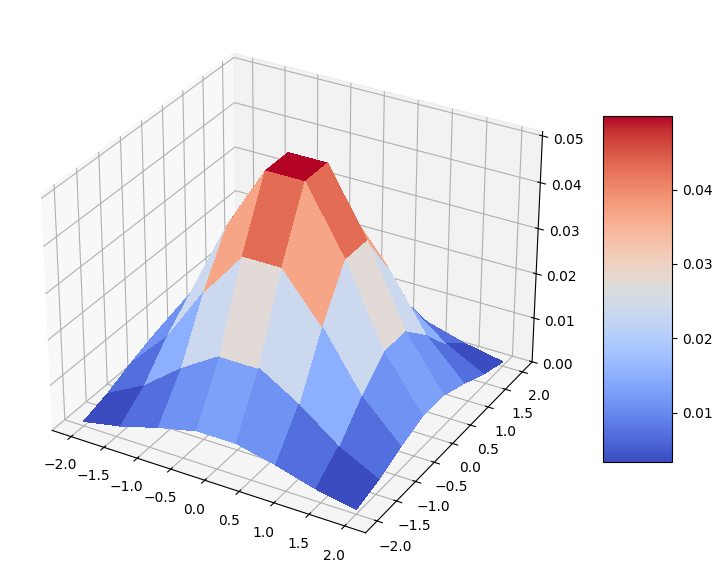

In [4]:
# 확률 분포를 3D 서페이스 플롯으로 시각화
import matplotlib.pyplot as plt
from matplotlib import cm

mesh_x, mesh_y = np.meshgrid(coords, coords)
grid_shape = (num_discrete_values, num_discrete_values)

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "3d"})
prob_grid = np.reshape(prob_data, grid_shape)
surf = ax.plot_surface(mesh_x, mesh_y, prob_grid, cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

## 3. 신경망의 정의
이 섹션에서 우리는 위에서 설명한 두 가지 신경망을 정의한다:

- 양자 신경망으로서의 양자 생성기.
- PyTorch 기반 신경망으로서의 고전 판별기.

### 3.1. 양자 신경망 앙상블의 정의

이제 양자 생성기에서 사용될 매개변수화된 양자 회로 $G\left(\boldsymbol{\theta}\right)$를 정의하며, $\boldsymbol{\theta} = {\theta_1, ..., \theta_k}$이다.

양자 생성기를 구현하기 위해 6번의 반복을 가진 하드웨어 효율적인 앙상블을 선택한다. 앙상블은 균등 분포를 입력 상태로 취하는 $R_Y$, $R_Z$ 회전 및 $CX$ 게이트를 구현한다. 특히 $k>1$의 경우 생성기의 매개변수를 신중하게 선택해야 한다. 예를 들어, 회로 깊이는 1보다 커야 한다. 왜냐하면 더 깊은 회로 깊이는 더 복잡한 구조의 표현을 가능하게 하기 때문이다. 여기서는 분포를 적절하게 캡처하고 표현할 수 있도록 많은 수의 매개변수를 가진 꽤 깊은 회로를 구성한다.

In [5]:
# 매개변수화된 양자 회로(앙상블) 생성
from qiskit import QuantumCircuit
from qiskit.circuit.library import efficient_su2

qc = QuantumCircuit(num_qubits)
qc.h(qc.qubits)

ansatz = efficient_su2(num_qubits, reps=6)
qc.compose(ansatz, inplace=True)

우리의 회로를 그려보고 어떻게 생겼는지 보자. 그래프에서 6번 나타나는 패턴을 볼 수 있다.

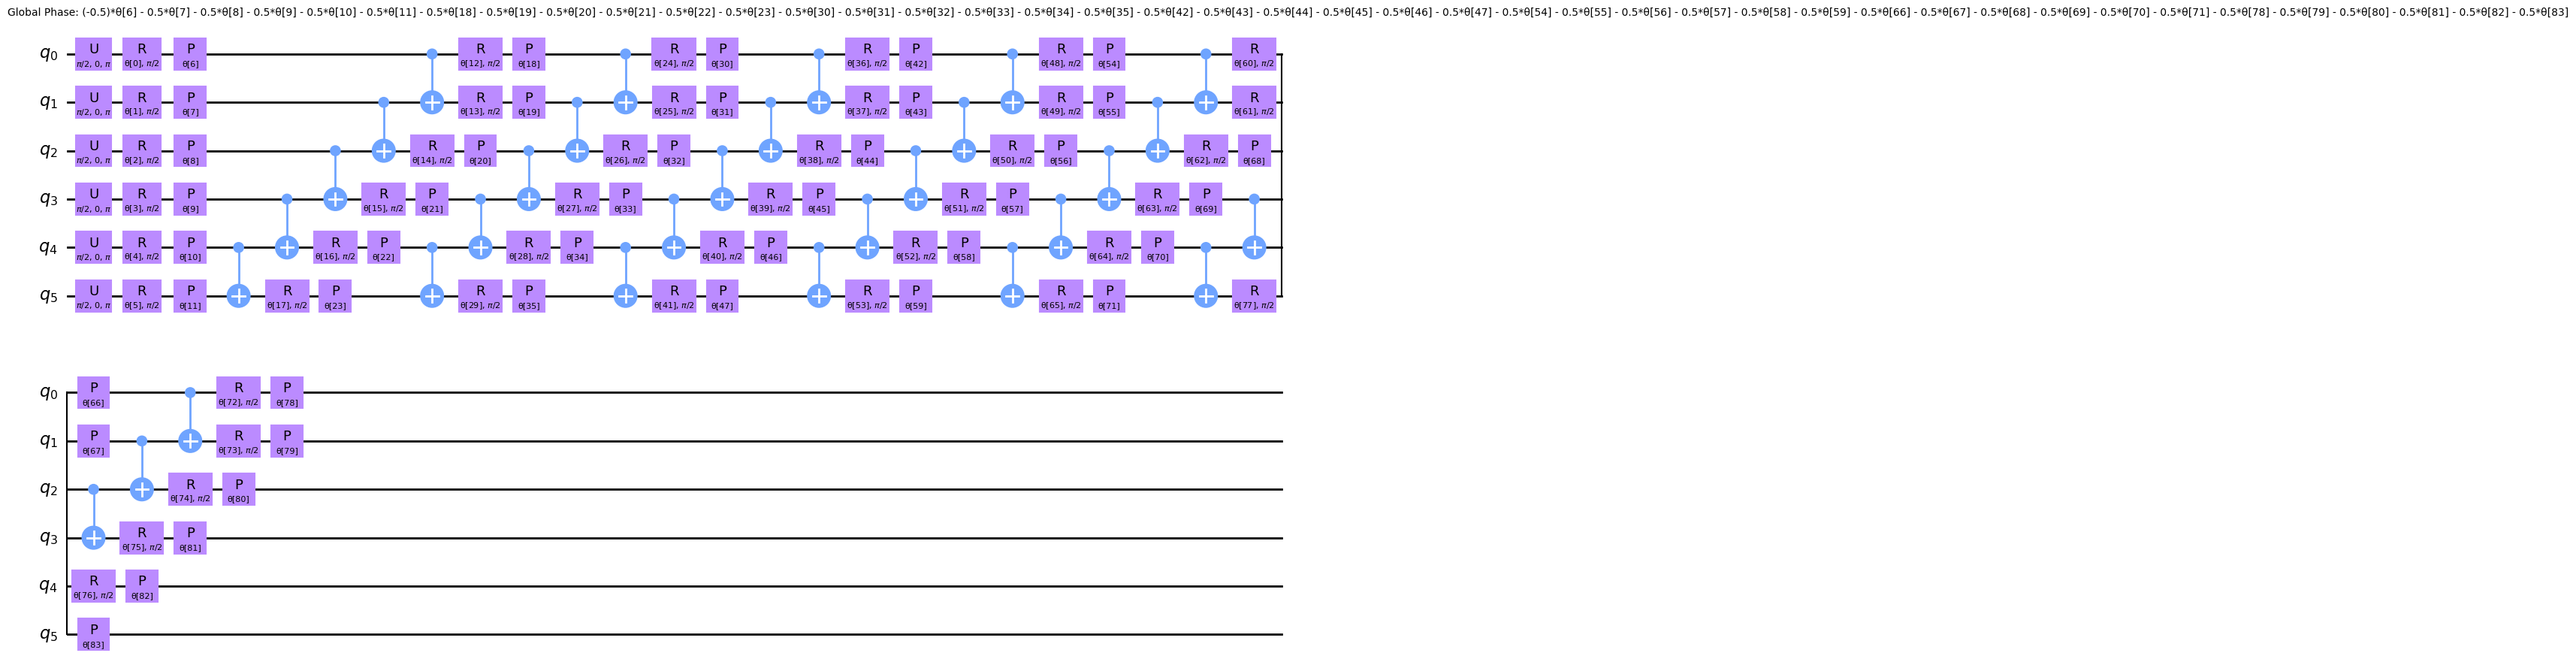

In [6]:
# 양자 회로를 분해하여 그림으로 그리기
qc.decompose().draw(output="mpl", style="clifford")

훈련 가능한 매개변수의 개수를 출력해 보자.

In [7]:
# 훈련 가능한 매개변수의 개수 확인
qc.num_parameters

84

### 3.2. 양자 생성기의 정의

앙상블에 대한 샘플러를 생성하여 생성기 정의를 시작한다. 참조 구현은 상태 벡터 기반 구현이므로 회로 실행 결과로 정확한 확률을 반환한다. 이 경우 구현은 측정된 준(quasi) 확률로부터 구성된 다항 분포에서 확률을 샘플링한다.

In [8]:
# 상태 벡터 기반 샘플러 생성
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

다음으로, 주어진 매개변수화된 양자 회로로부터 양자 생성기를 생성하는 함수를 정의한다. 이 함수 내에서 기본 Sampler(샘플러)에 의해 평가된 준(quasi) 확률 분포를 반환하는 신경망을 생성한다. 재현성 목적으로 `initial_weights`를 고정한다. 마지막에 생성된 양자 신경망을 `TorchConnector`로 감싸서 PyTorch 기반 훈련을 활용할 수 있도록 한다.

In [9]:
# 양자 신경망을 생성하는 함수 정의 및 TorchConnector로 감싸기
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN


def create_generator() -> TorchConnector:
    qnn = SamplerQNN(
        circuit=qc,
        sampler=sampler,
        input_params=[],
        weight_params=qc.parameters,
        sparse=False,
    )

    initial_weights = algorithm_globals.random.random(qc.num_parameters)
    return TorchConnector(qnn, initial_weights)

### 3.3. 고전 판별기의 정의

다음으로 고전 판별기를 나타내는 PyTorch 기반 고전 신경망을 정의한다. 기본 기울기는 PyTorch로 자동으로 계산할 수 있다.

In [10]:
# PyTorch 기반 고전 판별기 신경망 클래스 정의
from torch import nn


class Discriminator(nn.Module):
    def __init__(self, input_size):
        super(Discriminator, self).__init__()

        self.linear_input = nn.Linear(input_size, 20)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.linear20 = nn.Linear(20, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        x = self.linear_input(input)
        x = self.leaky_relu(x)
        x = self.linear20(x)
        x = self.sigmoid(x)
        return x

### 3.4. 생성기와 판별기 생성

이제 생성기와 판별기를 생성한다.

In [11]:
# 생성기와 판별기 인스턴스 생성
generator = create_generator()
discriminator = Discriminator(num_dim)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


## 4. 훈련 루프 설정
이 섹션에서 우리는 다음을 설정한다:

- 생성기 및 판별기에 대한 손실 함수.
- 둘 다에 대한 최적화 프로그램.
- 훈련 과정을 시각화하는 유틸리티 플로팅 함수.

### 4.1. 손실 함수의 정의
생성기와 판별기를 이진 교차 엔트로피(binary cross entropy)를 손실 함수로 훈련하려고 한다:
$$L\left(\boldsymbol{\theta}\right)=\sum_jp_j\left(\boldsymbol{\theta}\right)\left[y_j\log(x_j) + (1-y_j)\log(1-x_j)\right],$$
여기서 $x_j$는 데이터 샘플을 나타내고 $y_j$는 해당 레이블을 나타낸다.

PyTorch의 `binary_cross_entropy`는 가중치에 대해 미분 불가능하므로, 기울기를 평가할 수 있도록 손실 함수를 수동으로 구현한다.

In [12]:
# 이진 교차 엔트로피 손실 함수 정의
def adversarial_loss(input, target, w):
    bce_loss = target * torch.log(input) + (1 - target) * torch.log(1 - input)
    weighted_loss = w * bce_loss
    total_loss = -torch.sum(weighted_loss)
    return total_loss

### 4.2. 최적화 프로그램의 정의
생성기와 판별기를 훈련하기 위해 최적화 방식을 정의해야 한다. 다음에서 우리는 Adam이라는 모멘텀 기반 옵티마이저를 사용한다. 자세한 내용은 [Kingma et al., Adam: A method for stochastic optimization](https://arxiv.org/abs/1412.6980)을 참고하기 바란다.

In [13]:
# Adam 옵티마이저를 사용하여 생성기와 판별기의 최적화 프로그램 설정
from torch.optim import Adam

lr = 0.01  # learning rate
b1 = 0.7  # first momentum parameter
b2 = 0.999  # second momentum parameter

generator_optimizer = Adam(generator.parameters(), lr=lr, betas=(b1, b2), weight_decay=0.005)
discriminator_optimizer = Adam(
    discriminator.parameters(), lr=lr, betas=(b1, b2), weight_decay=0.005
)

### 4.3. 훈련 과정의 시각화
우리는 훈련 중에 생성기와 판별기의 손실 함수의 진화뿐만 아니라 훈련된 분포와 목표 분포 사이의 상대 엔트로피의 진행을 플로팅함으로써 훈련 중에 무엇이 일어나고 있는지를 시각화할 것이다. 손실 함수와 상대 엔트로피를 플로팅하는 함수를 정의한다. 우리는 훈련의 한 에포크가 완료되면 이 함수를 호출한다.

훈련 과정의 시각화는 훈련 데이터가 두 에포크에 걸쳐 수집되면 시작된다.

In [14]:
# 훈련 과정 중 손실 및 상대 엔트로피를 시각화하는 함수 정의
from IPython.display import clear_output


def plot_training_progress():
    # we don't plot if we don't have enough data
    if len(generator_loss_values) < 2:
        return

    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

    # Generator Loss
    ax1.set_title("Loss")
    ax1.plot(generator_loss_values, label="generator loss", color="royalblue")
    ax1.plot(discriminator_loss_values, label="discriminator loss", color="magenta")
    ax1.legend(loc="best")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Loss")
    ax1.grid()

    # Relative Entropy
    ax2.set_title("Relative entropy")
    ax2.plot(entropy_values)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Relative entropy")
    ax2.grid()

    plt.show()

## 5. 모델 훈련
훈련 루프에서 우리는 손실 함수뿐만 아니라 상대 엔트로피도 모니터링한다. 상대 엔트로피는 분포를 위한 거리 메트릭을 설명한다. 따라서 훈련된 분포가 목표 분포와 얼마나 가깝거나 먼지를 벤치마크하는 데 사용할 수 있다.

이제 모델을 훈련할 준비가 되었다. 모델을 훈련하는 데 시간이 걸릴 수 있으니 기다려 달라.

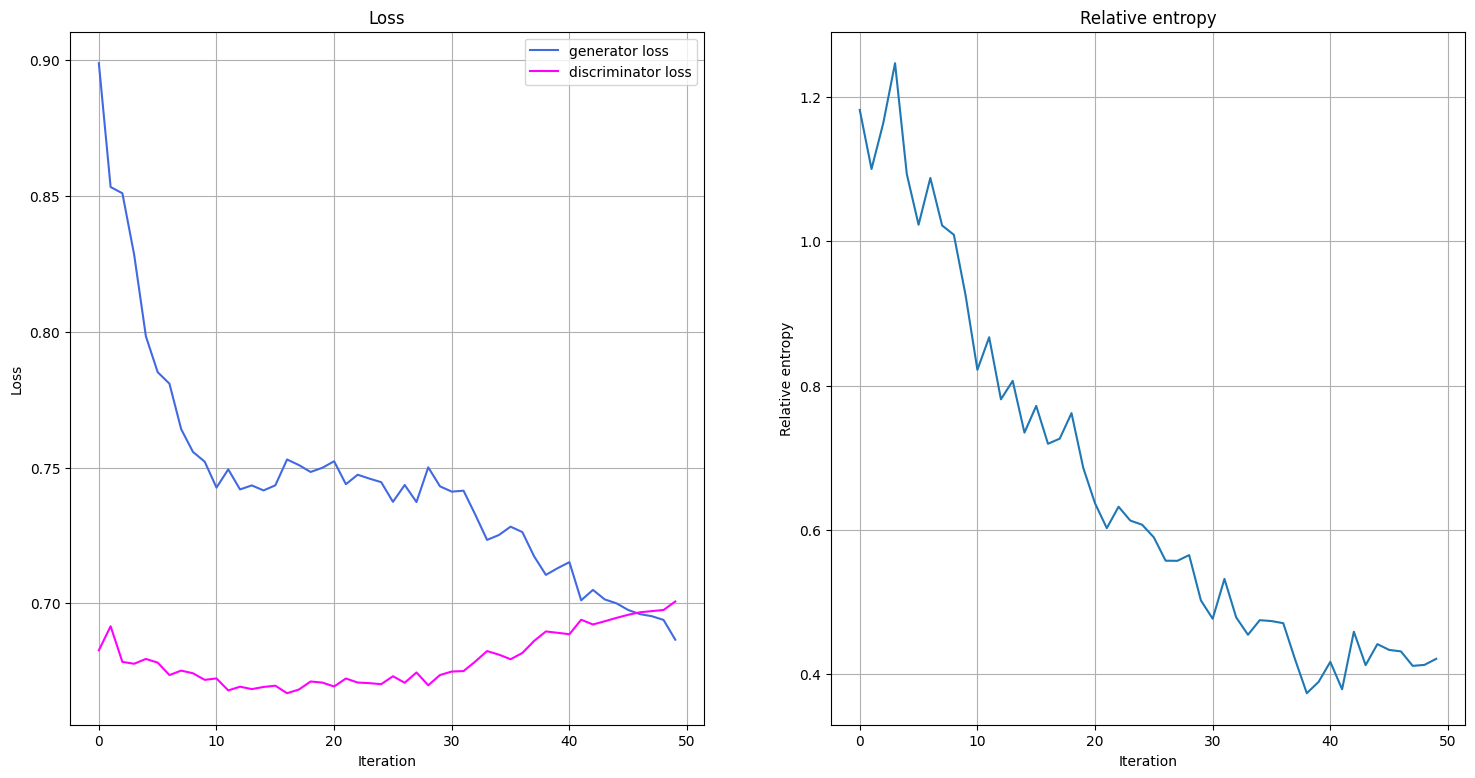

Fit in 37.86 sec


In [15]:
# 생성기와 판별기를 교대로 훈련하는 메인 훈련 루프
import time
from scipy.stats import multivariate_normal, entropy

n_epochs = 50

num_qnn_outputs = num_discrete_values**num_dim

generator_loss_values = []
discriminator_loss_values = []
entropy_values = []

start = time.time()
for epoch in range(n_epochs):

    valid = torch.ones(num_qnn_outputs, 1, dtype=torch.float)
    fake = torch.zeros(num_qnn_outputs, 1, dtype=torch.float)

    # Configure input
    real_dist = torch.tensor(prob_data, dtype=torch.float).reshape(-1, 1)

    # Configure samples
    samples = torch.tensor(grid_elements, dtype=torch.float)
    disc_value = discriminator(samples)

    # Generate data
    gen_dist = generator(torch.tensor([])).reshape(-1, 1)

    # Train generator
    generator_optimizer.zero_grad()
    generator_loss = adversarial_loss(disc_value, valid, gen_dist)

    # store for plotting
    generator_loss_values.append(generator_loss.detach().item())

    generator_loss.backward(retain_graph=True)
    generator_optimizer.step()

    # Train Discriminator
    discriminator_optimizer.zero_grad()

    real_loss = adversarial_loss(disc_value, valid, real_dist)
    fake_loss = adversarial_loss(disc_value, fake, gen_dist.detach())
    discriminator_loss = (real_loss + fake_loss) / 2

    # Store for plotting
    discriminator_loss_values.append(discriminator_loss.detach().item())

    discriminator_loss.backward()
    discriminator_optimizer.step()

    entropy_value = entropy(gen_dist.detach().squeeze().numpy(), prob_data)
    entropy_values.append(entropy_value)

    plot_training_progress()

elapsed = time.time() - start
print(f"Fit in {elapsed:0.2f} sec")

## 6. 결과: 누적 밀도 함수
이 섹션에서 우리는 훈련된 분포의 누적 분포 함수(CDF)를 목표 분포의 CDF와 비교한다.

먼저 모델을 더 이상 훈련하지 않을 것이므로 PyTorch autograd를 끄고 새 확률 분포를 생성한다.

In [16]:
# 훈련된 생성기에서 생성된 확률 분포 계산
with torch.no_grad():
    generated_probabilities = generator().numpy()

그리고 생성된 분포, 원본 분포 및 그 사이의 차이의 누적 분포 함수를 플로팅한다. 주의하기 바란다. 세 번째 그래프의 스케일 **은 첫 번째 및 두 번째 그래프와 같지 않다**이며, 플로팅된 두 CDF 사이의 실제 차이는 상당히 작다.

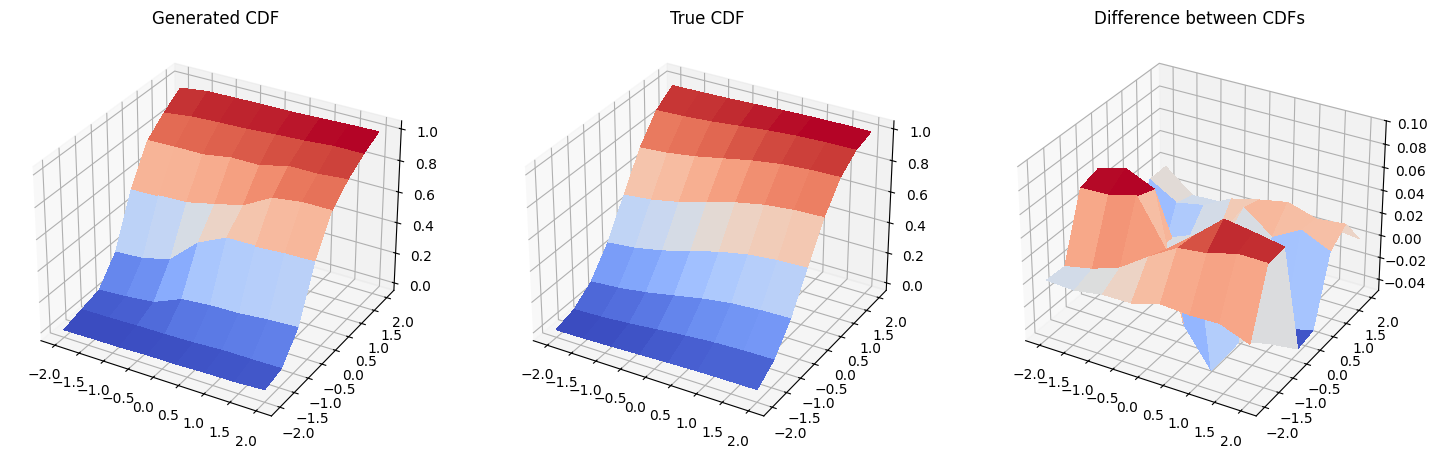

In [17]:
# 생성된 분포와 목표 분포의 누적 분포 함수(CDF) 비교 시각화
fig = plt.figure(figsize=(18, 9))

# Generated CDF
gen_prob_grid = np.reshape(np.cumsum(generated_probabilities), grid_shape)

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.set_title("Generated CDF")
ax1.plot_surface(mesh_x, mesh_y, gen_prob_grid, linewidth=0, antialiased=False, cmap=cm.coolwarm)
ax1.set_zlim(-0.05, 1.05)

# Real CDF
real_prob_grid = np.reshape(np.cumsum(prob_data), grid_shape)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.set_title("True CDF")
ax2.plot_surface(mesh_x, mesh_y, real_prob_grid, linewidth=0, antialiased=False, cmap=cm.coolwarm)
ax2.set_zlim(-0.05, 1.05)

# Difference
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.set_title("Difference between CDFs")
ax3.plot_surface(
    mesh_x, mesh_y, real_prob_grid - gen_prob_grid, linewidth=2, antialiased=False, cmap=cm.coolwarm
)
ax3.set_zlim(-0.05, 0.1)
plt.show()

## 7. 결론

양자 생성적 적대 신경망은 생성기와 판별기의 상호작용을 사용하여 주어진 데이터 샘플을 기본으로 하는 확률 분포의 근사 표현을 양자 채널로 매핑한다. 이 튜토리얼은 생성기가 양자 채널, 즉 변분 양자 회로로 주어지고 판별기가 고전 신경망으로 주어지는 독립적인 PyTorch 기반 qGAN 구현을 제시하며, 제네릭 확률 분포의 효율적인 학습과 양자 상태로의 로딩의 적용을 논의한다. 로딩에는 $\mathscr{O}\left(poly\left(n\right)\right)$ 게이트가 필요하며 따라서 잠재적으로 유리한 양자 알고리즘의 사용을 가능하게 할 수 있다.

In [18]:
# Qiskit 버전 정보 및 저작권 표시
import tutorial_magics

%qiskit_version_table
%qiskit_copyright